# XGBoost Sybil Detector — LayerZero

XGBoost, 3-seed ensemble (seeds 42, 123, 456), 5,000-round ceiling with early stopping (50 rounds) on
validation log-loss, on the stratified group split.

Training, evaluation and helper code live in `sybil_pipeline.py` (`sp.fit_xgb`, `sp.evaluate`), the same
code `11_split_comparison` runs on the original random split.

**Results**: test metrics in section 3, saved to `results/03_xgboost_sybil.json`.

## Setup

In [1]:
import warnings
import sybil_pipeline as sp
warnings.filterwarnings('ignore')

DATA_DIR = './data'
FEATS = sp.FEATS   # 62 model features (defined in sybil_pipeline.py)

## 1. Data and split

Stratified group split on gas provision trees (49 % train, 21 % validation, 30 % test); the Sybil class is
upsampled to 1:1 in the training partition only.

In [2]:
# ── Feature table (steps 1-7; see 00_data_pipeline) and the stratified group split ──
df, _, _ = sp.build_master_df(DATA_DIR)
S = sp.make_splits(df, FEATS, method='group', seed=sp.SEED)   # asserts no gas provision tree spans two partitions
print(sp.split_summary(df, S).to_string(index=False))
print(f"Train after upsampling: {len(S['X_train']):,} rows ({S['y_train'].mean()*100:.1f}% Sybil)\n")
leak = sp.leakage_report(df, S)

[1] L0 features: 434,786 addresses, 55 cols


[2] Gas provision: 604,365 edges before 2024-05-02 00:00:00 UTC (296 later edges dropped)


[3] Labeled addresses in provision network: 4,308


[4] Provider and tree features: 88 cols


[5] CEX/DEX merged: 90 cols


[6] Labels: Sybil=18,211 (4.19%)


[7] Chain features, taxonomy, gas provision trees (371,764 trees)


All 62 features present ✓  (60.6s)


     Split  Total  Sybil  NonSybil  SybilPct
     Train 213046   8924    204122      4.19
Validation  91305   3824     87481      4.19
      Test 130435   5463    124972      4.19
Train after upsampling: 408,244 rows (50.0% Sybil)



Split method: group
Row overlap (train/val, train/test, val/test): 0, 0, 0
Test addresses sharing a gas provision tree with a train address: 0 / 130,435
Test Sybils sharing a gas provision tree with a train Sybil:     0 / 5,463


## 2. Train (3 seeds, early stopping on validation)

Hyperparameters selected on validation by `02_hyperparameter_search`.

In [3]:
XGB_SELECTED, LGBM_SELECTED = sp.load_selected_params()
PARAMS = XGB_SELECTED
print('Tuned hyperparameters:', PARAMS)
m = sp.fit_xgb(S, PARAMS)

Tuned hyperparameters: {'learning_rate': 0.05, 'max_depth': 8, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 1}


  XGBoost seed=42  rounds=1679  99.3s


  XGBoost seed=123  rounds=1617  89.8s


  XGBoost seed=456  rounds=1578  87.4s


## 3. Evaluate on the test set

Threshold: the F1-maximizing threshold on validation.

  Threshold : 0.5824
  Precision : 0.7196
  Recall    : 0.7205
  F1        : 0.7200
  AUROC     : 0.9657
  Avg Prec  : 0.7645
  Brier     : 0.0197


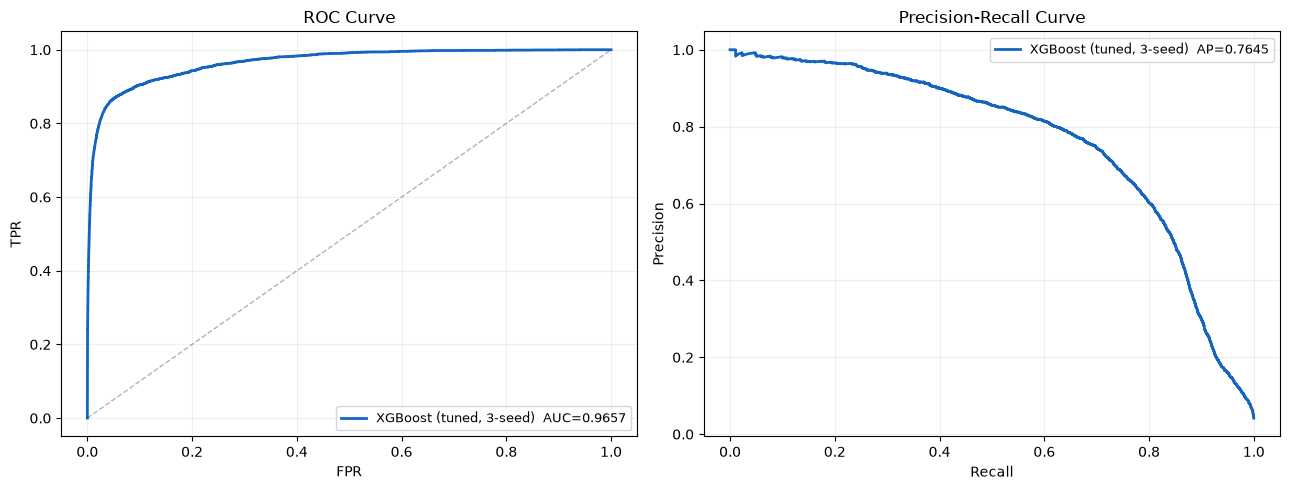

In [4]:
res = sp.evaluate('XGBoost (tuned, 3-seed)', S['y_val'], m['val'], S['y_test'], m['test'])
sp.print_metrics(res)
sp.plot_curves([res])

## 4. Feature importances

Total gain: the reduction in training loss summed over every split on the feature, normalized to sum to 1
for each model and averaged over the three seeds (`sp.gain_importance`). Gain credits correlated features
unevenly; `09_shap_importance` reports SHAP values and sums them by feature family.

Top 20 features (normalized total gain, mean over 3 seeds):
                          Feature  NormGain
                  l0_tx_time_span  0.225214
              num_transactions_in  0.082668
             l0_avg_stargate_swap  0.063265
            n_l0_source_contracts  0.049595
              earliest_l0_tx_time  0.048238
                 max_tx_value_out  0.045587
                latest_l0_tx_time  0.041518
             earliest_tx_block_in  0.040433
       gas_provision_block_number  0.033138
           tx_value_per_block_out  0.032809
                     time_span_in  0.030862
               n_l0_source_chains  0.030242
                  min_tx_value_in  0.025118
    n_l0_project_per_source_chain  0.023459
                    n_l0_projects  0.017038
                 provider_fan_out  0.013623
                 min_tx_value_out  0.013071
provider_min_gas_provision_amount  0.012781
               n_eth_interactions  0.011782
provider_avg_gas_provision_amount  0.011598


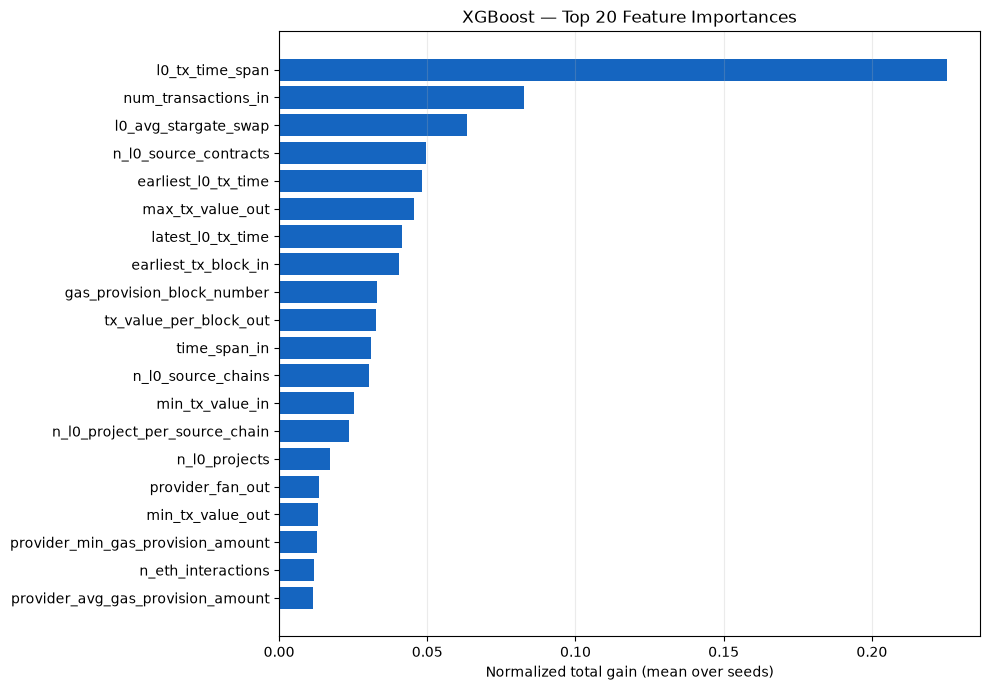

In [5]:
imp_df = sp.gain_importance(m['models'], FEATS)
print('Top 20 features (normalized total gain, mean over 3 seeds):')
print(imp_df.head(20).to_string(index=False))
sp.plot_importance(imp_df, 'XGBoost — Top 20 Feature Importances', '#1565C0')

## 5. Operating points

Precision, recall and counts on the test set at fixed thresholds and at the threshold chosen on validation
(whose row equals the reported test metrics).

In [6]:
print(sp.operating_points(S['y_test'], m['test'], res['threshold']).round(4).to_string(index=False))

 threshold  precision  recall     f1  flagged  false_pos                 note
    0.9500     0.8636  0.4843 0.6206     3064        418                     
    0.9000     0.8299  0.5682 0.6746     3740        636                     
    0.8500     0.8075  0.6105 0.6953     4130        795                     
    0.8000     0.7913  0.6372 0.7059     4399        918                     
    0.7500     0.7743  0.6614 0.7134     4666       1053                     
    0.7000     0.7575  0.6833 0.7185     4928       1195                     
    0.5824     0.7196  0.7205 0.7200     5470       1534 validation threshold
    0.5000     0.6935  0.7388 0.7154     5820       1784                     


## Save results

Scalar metrics go to `results/03_xgboost_sybil.json` with the code commit, so every number in the paper can be traced
to one run. Validation and test probabilities go to `output/` for `06_cross_ensemble_sybil` and `10_tie_out`.

In [7]:
sp.save_results([res], '03_xgboost_sybil', leakage=leak,
                extra=dict(params=PARAMS, rounds=m['rounds'],
                           importance=imp_df.set_index('Feature')['NormGain'].to_dict()))
sp.save_predictions(df, S, '03_xgboost_sybil', prob_xgb=m)

Saved results/03_xgboost_sybil.json
Saved output/pred_03_xgboost_sybil_val.parquet (91,305 rows)


Saved output/pred_03_xgboost_sybil_test.parquet (130,435 rows)
